In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/delhi_2019_all_stations.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

station = 'Patparganj'
df_st = df[df['Station'] == station].copy()

df_st = df_st.set_index('Timestamp').resample('1H').mean(numeric_only=True)
df_st = df_st.ffill().bfill()

df_st['Hour'] = df_st.index.hour
df_st['DayOfWeek'] = df_st.index.dayofweek
df_st['Month'] = df_st.index.month
df_st['IsWeekend'] = (df_st['DayOfWeek'] >= 5).astype(int)

for lag in [1, 2, 4, 8, 24, 48]:
    df_st[f'PM25_lag{lag}'] = df_st['PM25'].shift(lag)

df_st['PM25_roll24_mean'] = df_st['PM25'].shift(1).rolling(24).mean()
df_st['PM25_roll24_std'] = df_st['PM25'].shift(1).rolling(24).std()
df_st['PM25_roll168_mean'] = df_st['PM25'].shift(1).rolling(168).mean()

required_cols = [
    'PM25_lag48',
    'PM25_roll24_mean',
    'PM25_roll168_mean'
]

df_st = df_st.dropna(subset=required_cols)

print("Shape after feature engineering:", df_st.shape)
print("Date range:", df_st.index.min(), "→", df_st.index.max())
print("Features:", df_st.shape[1])

Shape after feature engineering: (8592, 38)
Date range: 2019-01-08 00:00:00 → 2019-12-31 23:00:00
Features: 38


In [2]:
# Time split
train = df_st[df_st.index < '2019-10-01']
val   = df_st[(df_st.index >= '2019-10-01') & (df_st.index < '2019-11-01')]
test  = df_st[df_st.index >= '2019-11-01']

print(f"Train: {len(train)} hours ({train.index.min().date()} → {train.index.max().date()})")
print(f"Val:   {len(val)} hours ({val.index.min().date()} → {val.index.max().date()})")
print(f"Test:  {len(test)} hours ({test.index.min().date()} → {test.index.max().date()})")

target = 'PM25'

feature_cols = [
    'PM25_lag1','PM25_lag2','PM25_lag4','PM25_lag8','PM25_lag24','PM25_lag48',
    'PM25_roll24_mean','PM25_roll24_std','PM25_roll168_mean',
    'NO2','CO','AT','RH','WS','SR','BP',
    'Hour','DayOfWeek','Month','IsWeekend'
]

# Ensure all features exist
feature_cols = [col for col in feature_cols if col in df_st.columns]

X_train = train[feature_cols]
y_train = train[target]

X_val   = val[feature_cols]
y_val   = val[target]

X_test  = test[feature_cols]
y_test  = test[target]

print(f"\nFeatures used: {len(feature_cols)}")
print(f"Target: {target}")

# Metrics function (fixed)
def evaluate(y_true, y_pred, model_name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1, None))) * 100
    r2   = r2_score(y_true, y_pred)

    baseline = np.full_like(y_true, y_train.mean())
    ss = 1 - rmse / np.sqrt(mean_squared_error(y_true, baseline))

    print(f"{model_name:20} | RMSE={rmse:.2f} | MAE={mae:.2f} | MAPE={mape:.1f}% | R²={r2:.3f} | SS={ss:.3f}")

    return {
        'Model': model_name,
        'RMSE': round(rmse, 2),
        'MAE': round(mae, 2),
        'MAPE': round(mape, 1),
        'R2': round(r2, 3),
        'SkillScore': round(ss, 3)
    }

results = []

Train: 6384 hours (2019-01-08 → 2019-09-30)
Val:   744 hours (2019-10-01 → 2019-10-31)
Test:  1464 hours (2019-11-01 → 2019-12-31)

Features used: 20
Target: PM25


In [3]:
# Naive baseline: predict t+1 = t
y_pred_persist = y_test.shift(1)

# Align properly
valid_idx = y_pred_persist.dropna().index
y_pred_persist = y_pred_persist.loc[valid_idx]
y_test_aligned = y_test.loc[valid_idx]

res = evaluate(y_test_aligned, y_pred_persist, 'Persistence')
results.append(res)

print("\nPersistence baseline done!")

Persistence          | RMSE=30.29 | MAE=19.23 | MAPE=11.6% | R²=0.948 | SS=0.836

Persistence baseline done!


In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

print("Fitting SARIMA...")

# Train series (already hourly, no need to resample again)
sarima_train = train['PM25']

sarima_model = SARIMAX(
    sarima_train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)
print("SARIMA fitted!")

# Forecast (val + test)
n_val = len(val)
n_test = len(test)

sarima_forecast = sarima_fit.forecast(steps=n_val + n_test)

# Split correctly
sarima_test_pred = sarima_forecast.iloc[n_val:n_val + n_test]

# Align index safely
sarima_test_pred.index = test.index

# Evaluate
res = evaluate(y_test, sarima_test_pred, 'SARIMA')
results.append(res)

print("SARIMA done!")

Fitting SARIMA...
SARIMA fitted!
SARIMA               | RMSE=233.69 | MAE=192.18 | MAPE=92.7% | R²=-2.080 | SS=-0.262
SARIMA done!


In [5]:
import xgboost as xgb

print("Training XGBoost...")

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

res = evaluate(y_test, y_pred_xgb, 'XGBoost')
results.append(res)

print("XGBoost done!")

Training XGBoost...
XGBoost              | RMSE=52.26 | MAE=24.94 | MAPE=13.0% | R²=0.846 | SS=0.718
XGBoost done!


In [6]:
!pip install lightgbm
import lightgbm as lgb

print("Training LightGBM...")

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(period=-1)]
)

y_pred_lgb = lgb_model.predict(X_test)
res = evaluate(y_test, y_pred_lgb, 'LightGBM')
results.append(res)
print("LightGBM done!")

Training LightGBM...
LightGBM             | RMSE=47.82 | MAE=23.55 | MAPE=12.3% | R²=0.871 | SS=0.742
LightGBM done!


In [7]:
from sklearn.ensemble import RandomForestRegressor

print("Training Random Forest...")

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
res = evaluate(y_test, y_pred_rf, 'Random Forest')
results.append(res)
print("Random Forest done!")

Training Random Forest...
Random Forest        | RMSE=44.44 | MAE=21.26 | MAPE=11.5% | R²=0.889 | SS=0.760
Random Forest done!


In [8]:
results_df = pd.DataFrame(results)
print("\n=== MODEL COMPARISON (Test Set: Nov-Dec 2019) ===\n")
print(results_df.sort_values('RMSE').to_string(index=False))
results_df.to_csv('../figures/27_model_results.csv', index=False)


=== MODEL COMPARISON (Test Set: Nov-Dec 2019) ===

        Model   RMSE    MAE  MAPE     R2  SkillScore
  Persistence  30.29  19.23  11.6  0.948       0.836
Random Forest  44.44  21.26  11.5  0.889       0.760
     LightGBM  47.82  23.55  12.3  0.871       0.742
      XGBoost  52.26  24.94  13.0  0.846       0.718
       SARIMA 233.69 192.18  92.7 -2.080      -0.262


Building LSTM...
Training LSTM...
LSTM                 | RMSE=54.36 | MAE=34.10 | MAPE=22.4% | R²=0.832 | SS=0.701
LSTM done!
Computing SHAP...


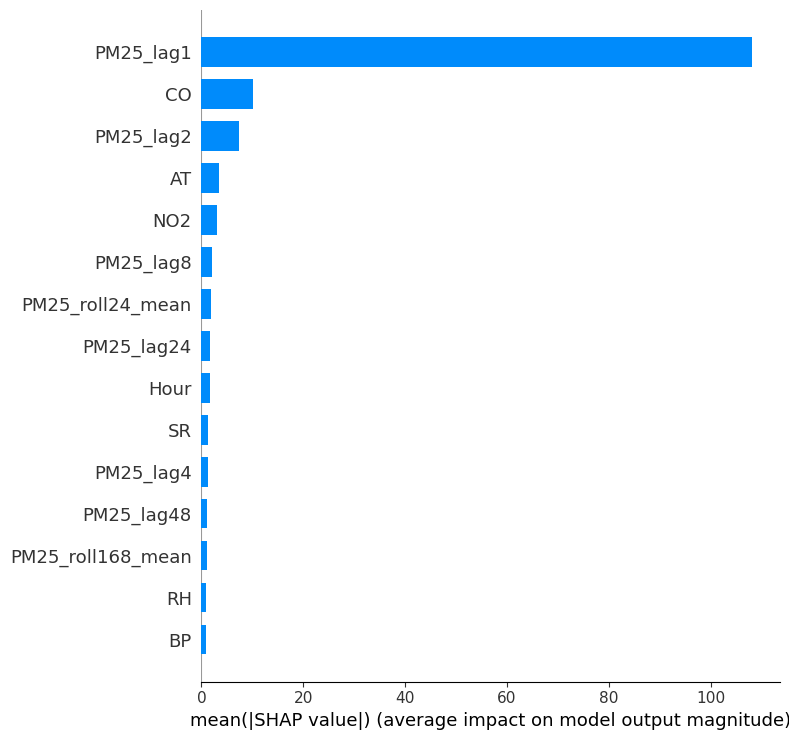

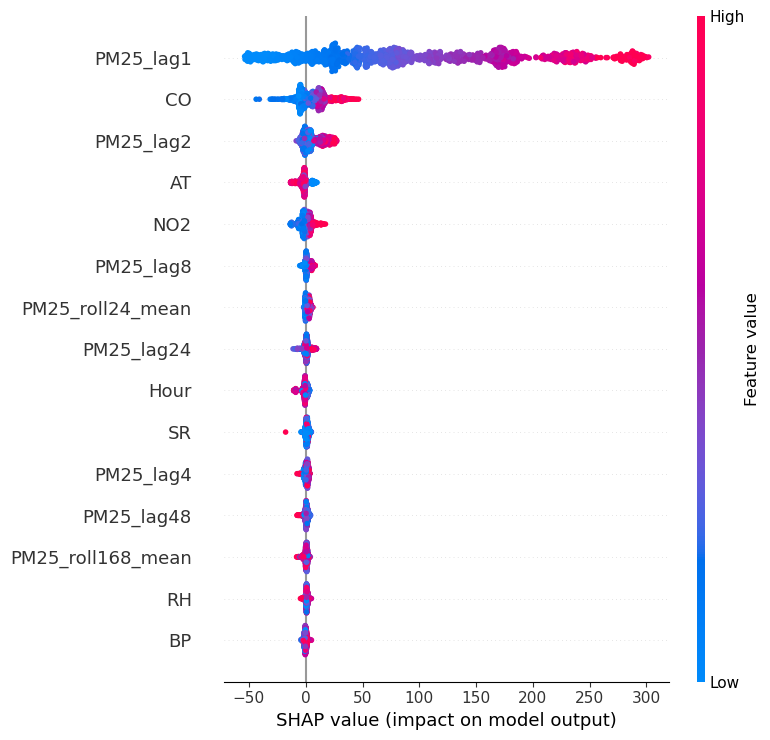

             Feature   Mean_SHAP
0          PM25_lag1  108.186508
10                CO   10.020877
1          PM25_lag2    7.440577
11                AT    3.414070
9                NO2    3.100949
3          PM25_lag8    2.085106
6   PM25_roll24_mean    1.930438
4         PM25_lag24    1.716056
16              Hour    1.588168
14                SR    1.329410
           Model    RMSE     MAE  MAPE     R2  SkillScore
0    Persistence   30.29   19.23  11.6  0.948       0.836
4  Random Forest   44.44   21.26  11.5  0.889       0.760
3       LightGBM   47.82   23.55  12.3  0.871       0.742
2        XGBoost   52.26   24.94  13.0  0.846       0.718
5           LSTM   54.36   34.10  22.4  0.832       0.701
1         SARIMA  233.69  192.18  92.7 -2.080      -0.262


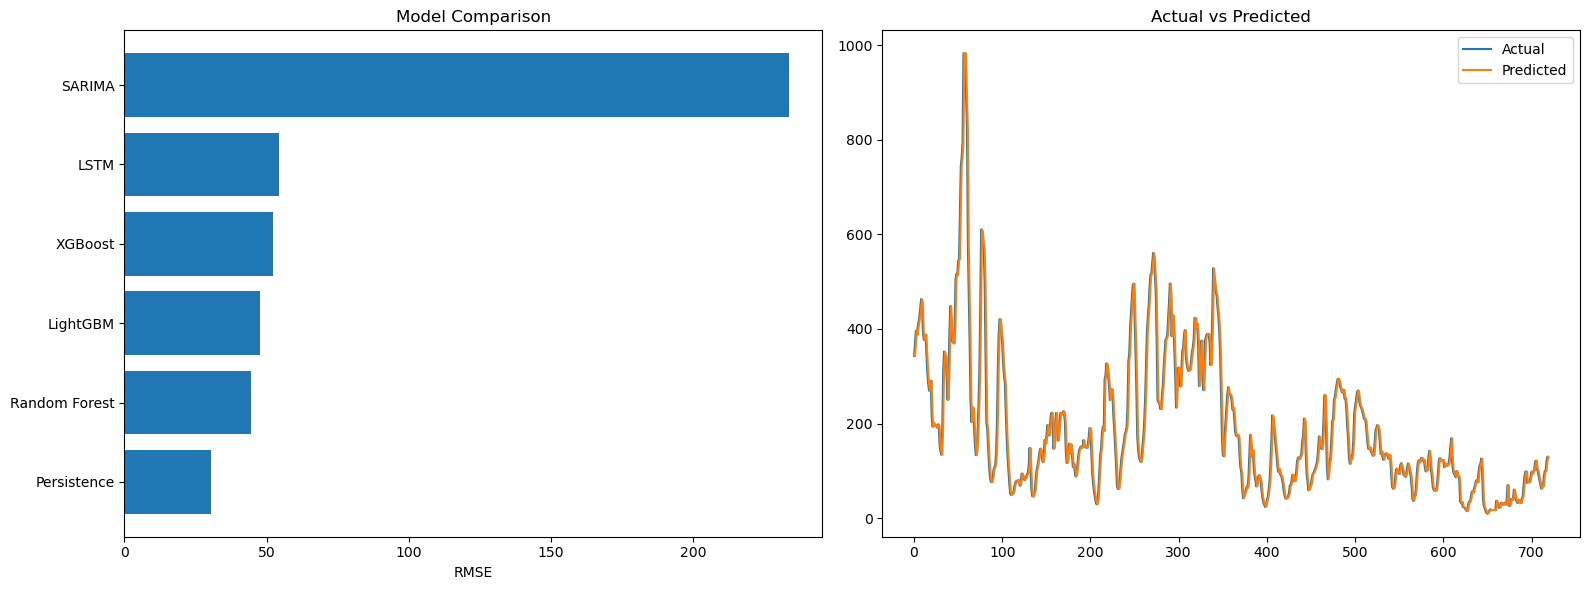

Saved!


In [9]:
# !pip install shap
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ================= LSTM =================

print("Building LSTM...")

scaler_lstm = StandardScaler()
X_train_scaled = scaler_lstm.fit_transform(X_train)
X_val_scaled   = scaler_lstm.transform(X_val)
X_test_scaled  = scaler_lstm.transform(X_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1,1)).flatten()

SEQ_LEN = 48

def make_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_tr_seq, y_tr_seq = make_sequences(X_train_scaled, y_train_scaled, SEQ_LEN)
X_val_seq, y_val_seq = make_sequences(
    X_val_scaled,
    y_scaler.transform(y_val.values.reshape(-1,1)).flatten(),
    SEQ_LEN
)
X_test_seq, y_test_seq = make_sequences(
    X_test_scaled,
    y_scaler.transform(y_test.values.reshape(-1,1)).flatten(),
    SEQ_LEN
)

X_tr_t  = torch.FloatTensor(X_tr_seq)
y_tr_t  = torch.FloatTensor(y_tr_seq)
X_val_t = torch.FloatTensor(X_val_seq)
y_val_t = torch.FloatTensor(y_val_seq)
X_te_t  = torch.FloatTensor(X_test_seq)

train_dl = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=128, shuffle=False)

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_lstm = LSTMModel(input_size=X_train.shape[1]).to(device)
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)

best_val_loss = float('inf')
best_model_state = None

print("Training LSTM...")

for epoch in range(30):
    model_lstm.train()
    losses = []
    for Xb, yb in train_dl:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model_lstm(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_lstm.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())

    model_lstm.eval()
    with torch.no_grad():
        val_pred = model_lstm(X_val_t.to(device)).cpu().numpy()
        val_loss = ((val_pred - y_val_seq) ** 2).mean()

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model_lstm.state_dict().copy()

model_lstm.load_state_dict(best_model_state)

with torch.no_grad():
    y_pred_lstm_scaled = model_lstm(X_te_t.to(device)).cpu().numpy()

y_pred_lstm = y_scaler.inverse_transform(y_pred_lstm_scaled.reshape(-1,1)).flatten()
y_test_lstm = y_test.iloc[SEQ_LEN:].values

res = evaluate(y_test_lstm, y_pred_lstm, 'LSTM')
results.append(res)

print("LSTM done!")

# ================= SHAP =================

print("Computing SHAP...")

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=15)
plt.tight_layout()
plt.savefig('../figures/28_shap_importance.png', dpi=150)
plt.show()

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.tight_layout()
plt.savefig('../figures/28b_shap_beeswarm.png', dpi=150)
plt.show()

shap_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False)

print(shap_df.head(10))

# ================= RESULTS =================

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('RMSE')

print(results_df)

results_df.to_csv('../figures/27_model_results.csv', index=False)

# ================= VISUALIZATION =================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(results_df['Model'], results_df['RMSE'])
axes[0].set_xlabel('RMSE')
axes[0].set_title('Model Comparison')

best_model = results_df.iloc[0]['Model']

if best_model == 'Persistence':
    y_pred_best = y_test.shift(1).dropna()
    y_true_best = y_test.loc[y_pred_best.index]
elif best_model == 'LSTM':
    y_pred_best = pd.Series(y_pred_lstm, index=y_test.index[SEQ_LEN:])
    y_true_best = y_test.iloc[SEQ_LEN:]
else:
    y_pred_best = pd.Series(y_pred_xgb, index=y_test.index)
    y_true_best = y_test

n = min(720, len(y_true_best))

axes[1].plot(y_true_best.values[:n], label='Actual')
axes[1].plot(y_pred_best.values[:n], label='Predicted')
axes[1].legend()
axes[1].set_title('Actual vs Predicted')

plt.tight_layout()
plt.savefig('../figures/27_model_comparison.png', dpi=150)
plt.show()

print("Saved!")


Ensemble (XGB+LGB+RF+LSTM) | RMSE=56.00 | MAE=30.51 | MAPE=18.9% | R²=0.814 | SS=0.688

=== FINAL MODEL COMPARISON TABLE ===

                     Model   RMSE    MAE  MAPE     R2  SkillScore
               Persistence  30.29  19.23  11.6  0.948       0.836
             Random Forest  44.44  21.26  11.5  0.889       0.760
                  LightGBM  47.82  23.55  12.3  0.871       0.742
                   XGBoost  52.26  24.94  13.0  0.846       0.718
                      LSTM  54.36  34.10  22.4  0.832       0.701
Ensemble (XGB+LGB+RF+LSTM)  56.00  30.51  18.9  0.814       0.688
                    SARIMA 233.69 192.18  92.7 -2.080      -0.262


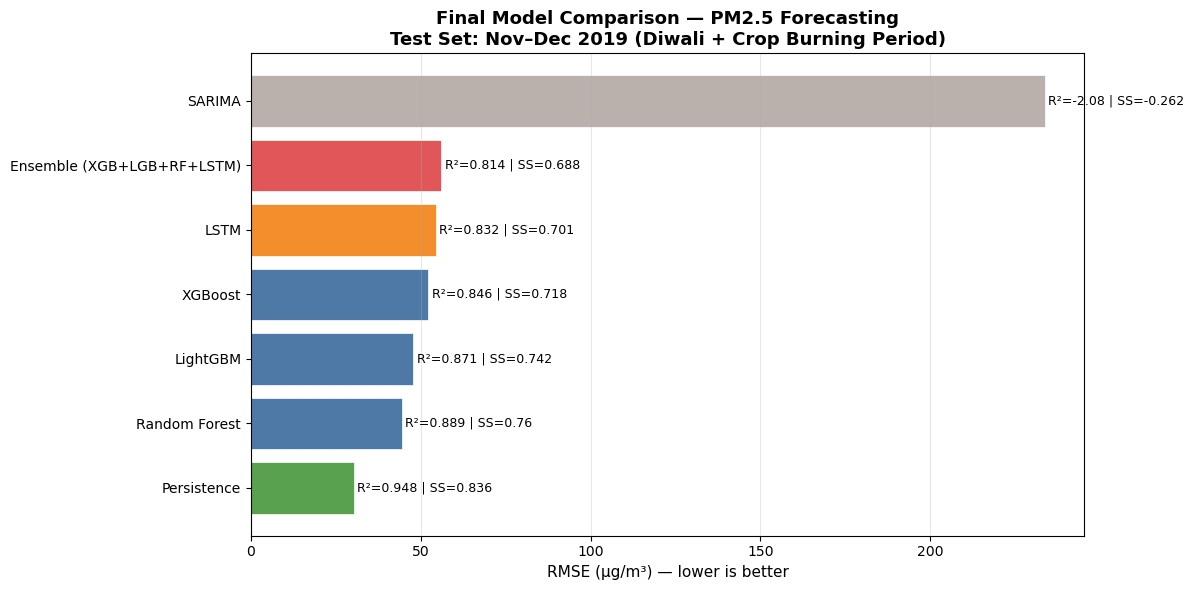

Saved!


In [10]:
# Ensemble: average XGBoost + LightGBM + Random Forest + LSTM
# Align all predictions to same length
min_len = min(len(y_pred_xgb), len(y_pred_lgb), 
              len(y_pred_rf), len(y_pred_lstm))

y_ensemble = (
    y_pred_xgb[:min_len] * 0.3 +
    y_pred_lgb[:min_len] * 0.3 +
    y_pred_rf[:min_len]  * 0.2 +
    y_pred_lstm[:min_len] * 0.2
)
y_test_ens = y_test.values[:min_len]

res = evaluate(y_test_ens, y_ensemble, 'Ensemble (XGB+LGB+RF+LSTM)')
results.append(res)

# Final table
results_df = pd.DataFrame(results).sort_values('RMSE')
print("\n=== FINAL MODEL COMPARISON TABLE ===\n")
print(results_df.to_string(index=False))
results_df.to_csv('../figures/29_final_results.csv', index=False)

# Final bar chart
fig, ax = plt.subplots(figsize=(12, 6))
color_map = {
    'Persistence': '#59a14f',
    'Random Forest': '#4e79a7',
    'LightGBM': '#4e79a7',
    'XGBoost': '#4e79a7',
    'LSTM': '#f28e2b',
    'Ensemble (XGB+LGB+RF+LSTM)': '#e15759',
    'SARIMA': '#bab0ac'
}
colors_final = [color_map.get(m, '#4e79a7') 
                for m in results_df['Model']]
bars = ax.barh(results_df['Model'], results_df['RMSE'],
               color=colors_final, edgecolor='white', linewidth=0.5)
ax.set_xlabel('RMSE (µg/m³) — lower is better', fontsize=11)
ax.set_title('Final Model Comparison — PM2.5 Forecasting\nTest Set: Nov–Dec 2019 (Diwali + Crop Burning Period)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
for i, (_, row) in enumerate(results_df.iterrows()):
    ax.text(row['RMSE']+1, i,
            f"R²={row['R2']} | SS={row['SkillScore']}",
            va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/29_final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")